# Pairwise Drivers Correlation in CMIP6 vs ERA5 Figure

In [1]:
%reload_ext autoreload
%autoreload 2
import os
import sys
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import seaborn as sns
import numpy as np
# Add the folder to the Python path

os.chdir("../")
# change working directory to project's root path
print(os.getcwd())

folder_path = os.path.abspath("functions/") #INPUT_PATH)#'path_to_your_folder')  # Replace with the actual folder path
sys.path.insert(0, folder_path)

c:\Users\marti\Desktop\data\hw_extra


In [2]:
path_drivers_all_scenarios_cmip6 = "data/03_primary/drivers/dfs_dict_ssps_v2.pickle"
with open(path_drivers_all_scenarios_cmip6, 'rb') as handle:
    all_dfs = pickle.load(handle)
path_drivers_historical = "data/03_primary/drivers/dfs_dict.pickle"
with open(path_drivers_historical, 'rb') as handle:
    historical_v1_dfs = pickle.load(handle)

In [3]:
with open("data/03_primary/drivers/era5_dict.pickle", 'rb') as handle:
    era5_v2 = pickle.load(handle)

In [4]:
historical_dfs = {
    model: scenario["historical"] for model, scenario in all_dfs.items()
}
historical_dfs["ERA5"] = era5_v2["ERA5"]

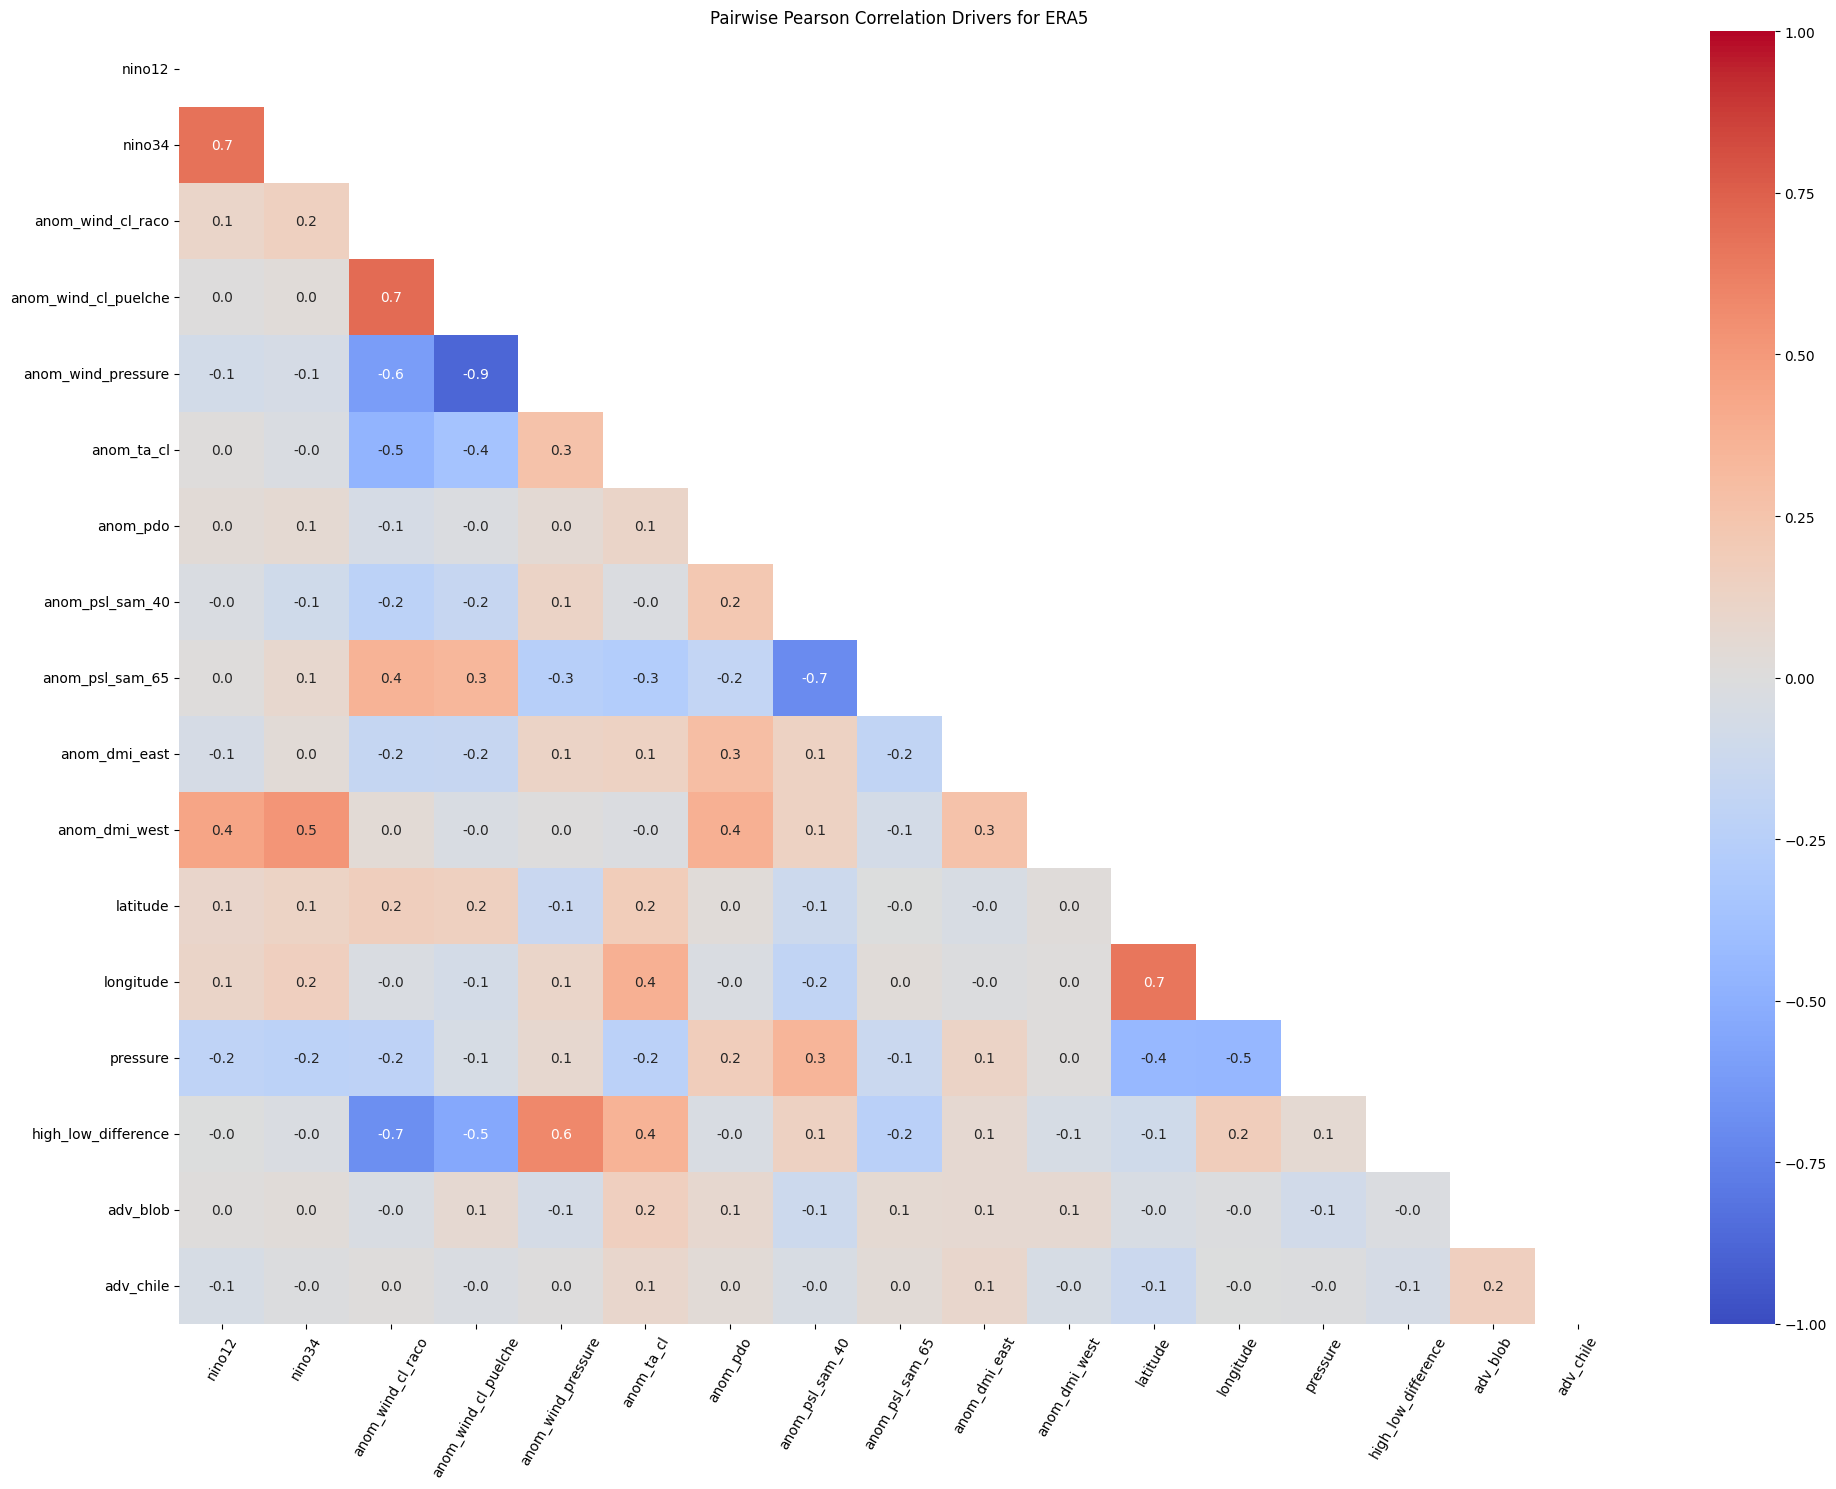

In [5]:

fig, ax = plt.subplots(figsize=(20,15))
# display(
df = historical_dfs["ERA5"].corr()
mask = np.triu(np.ones_like(df, dtype=bool))
sns.heatmap(df, annot=True, cmap='coolwarm', ax=ax, vmin=-1, vmax=1, cbar=True,  fmt=".1f", mask=mask)
    # .style.set_caption("Correlation for ERA5")
    # .background_gradient(cmap="coolwarm")
    # .format("{:.2f}")
    # )
ax.tick_params(axis='x', labelrotation=60)
ax.set_title(f"Pairwise Pearson Correlation Drivers for ERA5")
fig.tight_layout()

In [6]:
def flatten_corr_matrix(corr_df):
    return corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack()


model_corrs = {}


for model_name, df in historical_dfs.items():
    model_corrs[model_name] = flatten_corr_matrix(df.corr())

# Combine into one DataFrame
corr_comparison_df = pd.DataFrame(model_corrs).T  # Models as rows, correlations as columns
corr_comparison_df

nino12                                          
                 nino34 anom_wind_cl_raco anom_wind_cl_puelche   
MPI-ESM1-2-LR  0.710779          0.044985             0.003152  \
INM-CM5-0      0.585125          0.062543            -0.004474   
ACCESS-ESM1-5  0.824576          0.014415            -0.098620   
IPSL-CM6A-LR   0.818964          0.129545            -0.082832   
MPI-ESM1-2-HR  0.611321          0.114616             0.029192   
MRI-ESM2-0     0.875830          0.168066             0.006228   
EC-Earth3      0.790763          0.129318             0.051512   
GFDL-ESM4      0.694325          0.153809             0.049822   
MIROC6         0.797715          0.004642            -0.138070   
AWI-CM-1-1-MR  0.617820          0.076165             0.048961   
INM-CM4-8      0.510185          0.110068             0.051983   
ensemble_mean  0.837932          0.036439            -0.065577   
ERA5           0.675576          0.101779             0.007559   

                                                                        
              anom_wind_pressure anom_ta_cl  anom_pdo anom_psl_sam_40   
MPI-ESM1-2-LR          -0.009644   0.097314  0.210405       -0.078284  \
INM-CM5-0              -0.011138   0.185054  0.314228       -0.227235   
ACCESS-ESM1-5          -0.053664   0.095275  0.356980       -0.059239   
IPSL-CM6A-LR            0.013855   0.154916  0.205960       -0.236585   
MPI-ESM1-2-HR          -0.064331   0.136975  0.037010       -0.057082   
MRI-ESM2-0             -0.101740   0.051854 -0.019966       -0.092993   
EC-Earth3              -0.043398   0.150365  0.239199       -0.032852   
GFDL-ESM4              -0.069639   0.121195  0.130828        0.005163   
MIROC6                  0.040670   0.059780  0.071781       -0.002936   
AWI-CM-1-1-MR          -0.077823   0.142159  0.206807       -0.084248   
INM-CM4-8              -0.066678   0.208968  0.351984       -0.185430   
ensemble_mean           0.045027   0.372502  0.610889        0.168555   
ERA5                   -0.078564   0.012650  0.035624       -0.025813   

                                                           ... longitude   
              anom_psl_sam_65 anom_dmi_east anom_dmi_west  ...  pressure   
MPI-ESM1-2-LR       -0.095019      0.209517      0.488425  ... -0.329061  \
INM-CM5-0            0.058014      0.366452      0.402307  ... -0.290436   
ACCESS-ESM1-5        0.000315      0.151960      0.488577  ... -0.358459   
IPSL-CM6A-LR         0.102696      0.155589      0.385385  ... -0.408509   
MPI-ESM1-2-HR       -0.007044      0.018124      0.499657  ... -0.299802   
MRI-ESM2-0           0.099001     -0.159028      0.599315  ... -0.553814   
EC-Earth3            0.089795      0.039369      0.510818  ... -0.348314   
GFDL-ESM4            0.012004      0.073552      0.441053  ... -0.216177   
MIROC6              -0.002963     -0.032362      0.616509  ... -0.489279   
AWI-CM-1-1-MR        0.028649      0.285898      0.374075  ... -0.248724   
INM-CM4-8            0.144687      0.323285      0.452849  ... -0.417274   
ensemble_mean       -0.182814      0.535780      0.734225  ... -0.467366   
ERA5                 0.011009     -0.059692      0.437987  ... -0.452454   

                                                                 pressure   
              high_low_difference  adv_blob adv_chile high_low_difference   
MPI-ESM1-2-LR            0.502470 -0.058743 -0.016367           -0.070000  \
INM-CM5-0                0.294427 -0.024645 -0.014120            0.091520   
ACCESS-ESM1-5            0.444036 -0.073146 -0.051588            0.103456   
IPSL-CM6A-LR            -0.017816 -0.184249 -0.052892            0.244438   
MPI-ESM1-2-HR            0.583519 -0.102438  0.036981           -0.001073   
MRI-ESM2-0              -0.172730 -0.027812 -0.116129            0.408582   
EC-Earth3                0.097449 -0.129948  0.047801            0.140985   
GFDL-ESM4                0.286144 -0.092423 -0.103775            0.217559   
MIROC6             

In [7]:
diff_df = corr_comparison_df.subtract(corr_comparison_df.loc["ERA5"])

diff_df

nino12                                          
                 nino34 anom_wind_cl_raco anom_wind_cl_puelche   
MPI-ESM1-2-LR  0.035203         -0.056794            -0.004407  \
INM-CM5-0     -0.090451         -0.039236            -0.012032   
ACCESS-ESM1-5  0.149000         -0.087364            -0.106178   
IPSL-CM6A-LR   0.143388          0.027766            -0.090390   
MPI-ESM1-2-HR -0.064256          0.012837             0.021633   
MRI-ESM2-0     0.200254          0.066287            -0.001331   
EC-Earth3      0.115187          0.027539             0.043954   
GFDL-ESM4      0.018749          0.052030             0.042264   
MIROC6         0.122139         -0.097137            -0.145629   
AWI-CM-1-1-MR -0.057757         -0.025613             0.041403   
INM-CM4-8     -0.165391          0.008289             0.044425   
ensemble_mean  0.162356         -0.065339            -0.073135   
ERA5           0.000000          0.000000             0.000000   

                                                                        
              anom_wind_pressure anom_ta_cl  anom_pdo anom_psl_sam_40   
MPI-ESM1-2-LR           0.068920   0.084664  0.174781       -0.052471  \
INM-CM5-0               0.067426   0.172404  0.278604       -0.201423   
ACCESS-ESM1-5           0.024900   0.082625  0.321356       -0.033426   
IPSL-CM6A-LR            0.092419   0.142266  0.170336       -0.210772   
MPI-ESM1-2-HR           0.014232   0.124325  0.001386       -0.031269   
MRI-ESM2-0             -0.023176   0.039204 -0.055590       -0.067180   
EC-Earth3               0.035166   0.137715  0.203575       -0.007039   
GFDL-ESM4               0.008925   0.108545  0.095204        0.030976   
MIROC6                  0.119234   0.047130  0.036157        0.022877   
AWI-CM-1-1-MR           0.000741   0.129509  0.171183       -0.058435   
INM-CM4-8               0.011886   0.196318  0.316360       -0.159617   
ensemble_mean           0.123591   0.359852  0.575265        0.194368   
ERA5                    0.000000   0.000000  0.000000        0.000000   

                                                           ... longitude   
              anom_psl_sam_65 anom_dmi_east anom_dmi_west  ...  pressure   
MPI-ESM1-2-LR       -0.106029      0.269208      0.050437  ...  0.123393  \
INM-CM5-0            0.047004      0.426144     -0.035681  ...  0.162017   
ACCESS-ESM1-5       -0.010694      0.211652      0.050590  ...  0.093995   
IPSL-CM6A-LR         0.091687      0.215280     -0.052602  ...  0.043944   
MPI-ESM1-2-HR       -0.018053      0.077816      0.061670  ...  0.152652   
MRI-ESM2-0           0.087992     -0.099336      0.161327  ... -0.101360   
EC-Earth3            0.078786      0.099061      0.072831  ...  0.104140   
GFDL-ESM4            0.000994      0.133243      0.003065  ...  0.236276   
MIROC6              -0.013972      0.027330      0.178521  ... -0.036825   
AWI-CM-1-1-MR        0.017639      0.345590     -0.063913  ...  0.203730   
INM-CM4-8            0.133678      0.382976      0.014862  ...  0.035180   
ensemble_mean       -0.193823      0.595472      0.296238  ... -0.014912   
ERA5                 0.000000      0.000000      0.000000  ...  0.000000   

                                                                 pressure   
              high_low_difference  adv_blob adv_chile high_low_difference   
MPI-ESM1-2-LR            0.330551 -0.044127 -0.012662           -0.131703  \
INM-CM5-0                0.122508 -0.010029 -0.010416            0.029818   
ACCESS-ESM1-5            0.272118 -0.058530 -0.047883            0.041754   
IPSL-CM6A-LR            -0.189735 -0.169634 -0.049188            0.182736   
MPI-ESM1-2-HR            0.411601 -0.087823  0.040685           -0.062775   
MRI-ESM2-0              -0.344648 -0.013196 -0.112425            0.346880   
EC-Earth3               -0.074470 -0.115332  0.051506            0.079282   
GFDL-ESM4                0.114225 -0.077807 -0.100071            0.155857   
MIROC6             

In [13]:
df_diff_corrs = pd.DataFrame(index=diff_df.index, columns=["mean", "std", "min", "max", "out_2std"])
for index, row in diff_df.iterrows():
    df_diff_corrs.loc[index] = row.mean(), row.std(), row.min(), row.max(), (row[row> row.mean()+2*row.std()].count() + row[row< row.mean()-2*row.std()].count())/row.count()
df_diff_corrs

,mean,std,min,max,out_2std
MPI-ESM1-2-LR,-0.013414,0.124954,-0.657847,0.330551,0.058824
INM-CM5-0,0.007011,0.126827,-0.500646,0.426144,0.051471
ACCESS-ESM1-5,0.000619,0.107521,-0.403838,0.321356,0.051471
IPSL-CM6A-LR,-0.006105,0.116636,-0.517387,0.259297,0.022059
MPI-ESM1-2-HR,-0.010919,0.116271,-0.65398,0.411601,0.029412
MRI-ESM2-0,-0.012943,0.102026,-0.453936,0.34688,0.044118
EC-Earth3,0.019781,0.072226,-0.170606,0.203575,0.029412
GFDL-ESM4,-0.003127,0.091614,-0.48084,0.236276,0.044118
MIROC6,-0.00492,0.10114,-0.332598,0.270795,0.058824
AWI-CM-1-1-MR,0.002035,0.13437,-0.751902,0.444011,0.058824


In [14]:
display(
    df_diff_corrs
    .style.set_caption("Pairwise Correlation Difference Statistics")
    .background_gradient(cmap="coolwarm")
    .format({"mean":"{:.3f}", "std":"{:.2f}","min":"{:.2f}","max":"{:.2f}", "out_2std":"{:.1%}"})
)

,mean,std,min,max,out_2std
MPI-ESM1-2-LR,-0.013,0.12,-0.66,0.33,5.9%
INM-CM5-0,0.007,0.13,-0.50,0.43,5.1%
ACCESS-ESM1-5,0.001,0.11,-0.40,0.32,5.1%
IPSL-CM6A-LR,-0.006,0.12,-0.52,0.26,2.2%
MPI-ESM1-2-HR,-0.011,0.12,-0.65,0.41,2.9%
MRI-ESM2-0,-0.013,0.10,-0.45,0.35,4.4%
EC-Earth3,0.020,0.07,-0.17,0.20,2.9%
GFDL-ESM4,-0.003,0.09,-0.48,0.24,4.4%
MIROC6,-0.005,0.10,-0.33,0.27,5.9%
AWI-CM-1-1-MR,0.002,0.13,-0.75,0.44,5.9%
